# A union B: AMN growth and MINN flux transfer

One frozen A-union-B FluxTransformer is shared across independently trained front MLPs. AMN uses a medium-to-growth MLP. MINN trains two independent omics-to-context MLPs: measured and predicted glucose/oxygen context. Each outer fold starts a fresh MLP. Both MINN variants use observed glucose/oxygen bounds in downstream pFBA.

The notebook contains no generic tabular-model benchmark. Run from the repository root using its Python environment. The local union checkpoint is configured below; command provenance is optional. MINN runs one 50-trial, five-fold HPO study per context mode, then 29 leave-one-out fits with the selected parameters. Outputs remain empty until you execute it.

Implementation helpers: `iml1515_evaluation.py`. Protocol: `docs/working_notes/iML1515_AB_union_notebook_plan.md`. Historical A/B/C scores require matched reruns before comparison.

In [1]:
import os
import numpy as np
import seaborn as sns
from pathlib import Path
from datetime import datetime, timezone
import importlib.metadata
import subprocess

import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display

import iml1515_evaluation as ev
from importlib import reload
ev = reload(ev)  # Pick up evaluator changes when rerunning in an existing kernel.

ROOT = Path.cwd()
if not (ROOT / "flux_transformer.py").is_file():
    raise RuntimeError("Start the notebook in the metabolic-NN repository root.")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


## Run configuration

The local union checkpoint, training log and biomass test CSV are selected below. Run the notebook from the repository root. Generation/training command fields are optional documentation and may remain empty. A missing optional log or biomass CSV does not prevent AMN/MINN evaluation.

The checkpoint loss curves and biomass-only diagnostic appear before experimental training. Full A/B simulated fidelity is disabled by default; enable it only when you want that additional analysis and have set its test paths. Optional MINN target-file and cap-set sensitivities retain both context modes.

In [2]:
MODEL_FAMILY = "AB_union"
CHECKPOINT = ROOT / "models/AB_1M_d256_h8_l4_ff1024/AB_1M_d256_h8_l4_ff1024_checkpoint.pth"
TRAINING_LOG = ROOT / "models/AB_1M_d256_h8_l4_ff1024/AB_1M_d256_h8_l4_ff1024_training.log"
METADATA_JSON = None  # Only needed if the checkpoint lacks config/data_info.
TRAINING_PROVENANCE = {"generation_command": "", "training_command": "", "seed": 42}

RUN_SIMULATED = False  # Optional full A/B fidelity analysis.
BIOMASS_TEST_PATH = ROOT / "data/iML1515_AB_union_test_data_50000_samples.csv"
BIOMASS_BATCH_SIZE = 2
RUN_AMN = True
RUN_MINN = True
TARGET_MODES = ["minn_fitted"]  # Optional: "non_fitted", "iml1515_minn_like".
CAP_MODES = ["co2_etoh_ac_cap"]  # Optional additional sensitivity: "etoh_ac_cap".
SIMULATED = {
    "A": {"path": None, "seed": 9, "rows": 50000, "command": ""},
    "B": {"path": None, "seed": 9, "rows": 50000, "command": ""},
}
SIM_BATCH_SIZE = 2
OBJECTIVE_CHECK_SAMPLES = 100  # First 100 rows/domain
# All rows get mass/bound checks.
PFBA_FRACTION = 1.0  # Match model C downstream pFBA.
XML_PATH = ROOT / "models/iML1515.xml"
AMN_DIR, MINN_DIR = ROOT / "AMN_data", ROOT / "MINN_data"

AMN_SETTINGS = dict(folds=10, split_seeds=[10, 11, 12], train_seed=10,
    validation_protocol="legacy_outer_early_stopping", hidden=512, epochs=100, patience=15, min_delta=0.0,
    batch_size=1, validation_batch_size=2, delta=0.03, clip=None, amp=False, warmup=0,
    params={"drop_rate": 0.0, "learning_rate": 1e-3, "weight_decay": 1e-3})
MINN_SETTINGS = dict(legacy_protocol=True, seed=12345, inner_folds=5, trials=50, hidden=512,
    epochs=150, patience=25, min_delta=1e-5, batch_size=2 if DEVICE.type == "cuda" else 5, delta=1.0,
    clip=1.0, amp=DEVICE.type == "cuda", warmup=10, std_penalty=0.25,
    drop_rates=[0.0, 0.05, 0.1, 0.2, 0.3, 0.35, 0.4],
    lr_range=[5e-4, 1e-2], wd_range=[1e-8, 1e-3])
# Use a new directory for every execution
# Completed folds are saved immediately.
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")


In [3]:
required = {"CHECKPOINT": CHECKPOINT, "XML": XML_PATH}
if TRAINING_LOG is not None and Path(TRAINING_LOG).is_file():
    required["TRAINING_LOG"] = TRAINING_LOG
if BIOMASS_TEST_PATH is not None and Path(BIOMASS_TEST_PATH).is_file():
    required["biomass_test"] = BIOMASS_TEST_PATH
if METADATA_JSON is not None:
    required["METADATA_JSON"] = METADATA_JSON
if RUN_AMN:
    required.update({name: AMN_DIR / name for name in ("iML1515_EXP.csv", "EXP110.csv")})
if RUN_MINN:
    if not TARGET_MODES or len(set(TARGET_MODES)) != len(TARGET_MODES):
        raise ValueError("Specify unique MINN target modes.")
    if "co2_etoh_ac_cap" not in CAP_MODES or not set(CAP_MODES) <= {"co2_etoh_ac_cap", "etoh_ac_cap"}:
        raise ValueError("Keep the primary CO2/ethanol/acetate cap comparison enabled.")
    required.update({name: MINN_DIR / name for name in ("transcriptomics.csv", "proteomics.csv")})
    required.update({mode: MINN_DIR / ev.FLUX_FILES[mode] for mode in TARGET_MODES})
if RUN_SIMULATED:
    required.update({f"simulated_{key}": spec["path"] for key, spec in SIMULATED.items()})
missing = [name for name, path in required.items() if path is None or not Path(path).is_file()]
if missing:
    raise FileNotFoundError("Configure/provide these inputs before running: " + ", ".join(missing))
if RUN_SIMULATED and any(s["seed"] is not None and s["seed"] == TRAINING_PROVENANCE["seed"] for s in SIMULATED.values()):
    raise ValueError("Held-out generation seed must differ from the training seed.")

reservoir, input_names, output_names, architecture, training_info = ev.load_reservoir(CHECKPOINT, DEVICE, METADATA_JSON, model_family=MODEL_FAMILY)
model_name = Path(CHECKPOINT).parent.name
run_dir = ROOT / "pics" / model_name / "AB_union_evaluation" / RUN_ID
run_dir.mkdir(parents=True, exist_ok=False)
pic_dir = run_dir / "figures"
pic_dir.mkdir()
print("Architecture:", architecture)
print("Inputs:", len(input_names), "Outputs:", len(output_names))
print("Artifacts:", run_dir)


Architecture: {'d_model': 256, 'n_heads': 8, 'n_layers': 4, 'd_ff': 1024, 'dropout': 0.02, 'batch_size': 32, 'learning_rate': 0.0001, 'num_epochs': 18, 'requested_num_epochs': 20, 'training_end_epoch': 20, 'patience': 4, 'vocab_size': 2712, 'input_token_indices': [180, 1981, 45, 1525, 106, 40, 86, 92, 104, 164, 304, 621, 700, 859, 913, 934, 970, 1424, 1478, 1485, 1500, 1534, 1535, 1836, 2243, 2320, 633, 99, 108, 98, 1490, 217, 114, 1439, 288, 303, 206, 209, 347, 112, 111], 'output_sample_ratio': 1.0}
Inputs: 41 Outputs: 2712
Artifacts: c:\Users\truok\projects\metabolic-NN\pics\AB_1M_d256_h8_l4_ff1024\AB_union_evaluation\20260917T150631340189Z


In [4]:
manifest = {
    "model_family": MODEL_FAMILY, "run_id": RUN_ID, "checkpoint": str(CHECKPOINT), "architecture": architecture,
    "training_info": training_info, "training_provenance": TRAINING_PROVENANCE,
    "inputs": input_names, "outputs": output_names, "device": str(DEVICE),
    "objective": ev.OBJECTIVE, "pfba_fraction": PFBA_FRACTION,
    "amn_settings": AMN_SETTINGS, "minn_settings": MINN_SETTINGS,
    "target_modes": TARGET_MODES, "cap_modes": CAP_MODES, "simulated_specs": SIMULATED,
    "objective_check_samples": OBJECTIVE_CHECK_SAMPLES,
    "versions": {p: importlib.metadata.version(p) for p in ("torch", "numpy", "pandas", "scikit-learn", "cobra", "optuna")},
    "files": {name: {"path": str(path), "sha256": ev.file_hash(path)} for name, path in required.items()},
    "code_hashes": {name: ev.file_hash(ROOT / name) for name in
        ("iml1515_evaluation.py", "flux_transformer.py", "generate_ecoli_iML1515_AB_union_data.py", "ecoli_iML1515_AB_union_model_testing.ipynb")},
    "git_revision": subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip(),
    "status": "started", "deferred": ["C/intermediate fidelity", "broad D/E fidelity"],
}
ev.save_json(run_dir / "manifest.json", manifest)
# No automatic cache loading: fresh run directories prevent stale-mode/result reuse.
amn_result, minn_data, minn_results, pfba_results = None, {}, {}, {}
simulated_summary = None


## Checkpoint loss curves and biomass diagnostic

These use the same plotting functions and style as the earlier AMN notebook: a logarithmic loss graph and a 2?2 biomass diagnostic (true versus predicted, residuals, error distribution, and true-value distribution). The saved checkpoint calls its held-out loss `test_losses`; it is labelled Validation Loss here. Only biomass is plotted. Full-vocabulary inference is retained.


In [5]:
def plot_loss_curves(train_losses, test_losses, d_model, n_heads, n_layers, d_ff, save_path=None, log_scale=True):
    plt.figure(figsize=(14, 10))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.plot(train_losses, label="Training Loss")
    plt.plot(test_losses, label="Validation Loss")
    if log_scale:
        plt.yscale('log')
    plt.xlabel("Epoch", fontsize=18)
    plt.ylabel("Loss", fontsize=18)
    plt.title(f"Loss Curves (d={d_model}, h={n_heads}, l={n_layers}, ff={d_ff})", fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=16)
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.show()
        print(f"\nTraining curve saved to {save_path}")
    else:
        plt.show()

def plot_diagnostics_2x2(y_true, y_pred, label, save_path=None):
    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of samples."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    residuals = y_true - y_pred
    display_label = str(label)
    if display_label.endswith('_flux'):
        display_label = display_label[:-5]
    if display_label.upper().startswith('BIOMASS'):
        display_label = 'Model C iML1515 Biomass'

    title_fs = 15
    label_fs = 13
    tick_fs = 11

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    # True vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color='royalblue')
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    axs[0, 0].plot([lo, hi], [lo, hi], 'k--', lw=2)
    axs[0, 0].set_title(f'True vs Predicted: {display_label}', fontsize=title_fs)
    axs[0, 0].set_xlabel('True value', fontsize=label_fs)
    axs[0, 0].set_ylabel('Predicted', fontsize=label_fs)
    axs[0, 0].grid(True)

    # Residuals plot
    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color='darkorange')
    axs[0, 1].axhline(y=0, color='r', linestyle='-')
    axs[0, 1].set_title(f'Residuals: {display_label}', fontsize=title_fs)
    axs[0, 1].set_xlabel('True value', fontsize=label_fs)
    axs[0, 1].set_ylabel('Residuals', fontsize=label_fs)
    if str(label).upper().startswith('BIOMASS'):
        axs[0, 1].set_ylim(-0.05, 0.05)
    else:
        res_abs_max = float(np.nanmax(np.abs(residuals))) if residuals.size else 1.0
        if (not np.isfinite(res_abs_max)) or (res_abs_max == 0.0):
            res_abs_max = 1.0
        axs[0, 1].set_ylim(-res_abs_max, res_abs_max)
    axs[0, 1].grid(True)

    # Error distribution
    sns.histplot(residuals, kde=True, ax=axs[1, 0], legend=False, color='indianred')
    axs[1, 0].set_title(f'Prediction Error Distribution: {display_label}', fontsize=title_fs)
    axs[1, 0].set_xlabel('Prediction Error', fontsize=label_fs)
    axs[1, 0].set_ylabel('Frequency', fontsize=label_fs)
    axs[1, 0].grid(True)

    # Histogram of actual values
    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], legend=False, color='mediumseagreen')
    axs[1, 1].set_title(f'True Value Distribution: {display_label}', fontsize=title_fs)
    axs[1, 1].set_xlabel('True Value', fontsize=label_fs)
    axs[1, 1].set_ylabel('Frequency', fontsize=label_fs)
    axs[1, 1].grid(True)

    for ax in axs.ravel():
        ax.tick_params(labelsize=tick_fs)

    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.show()
        plt.close(fig)
    else:
        plt.show()
        plt.close(fig)

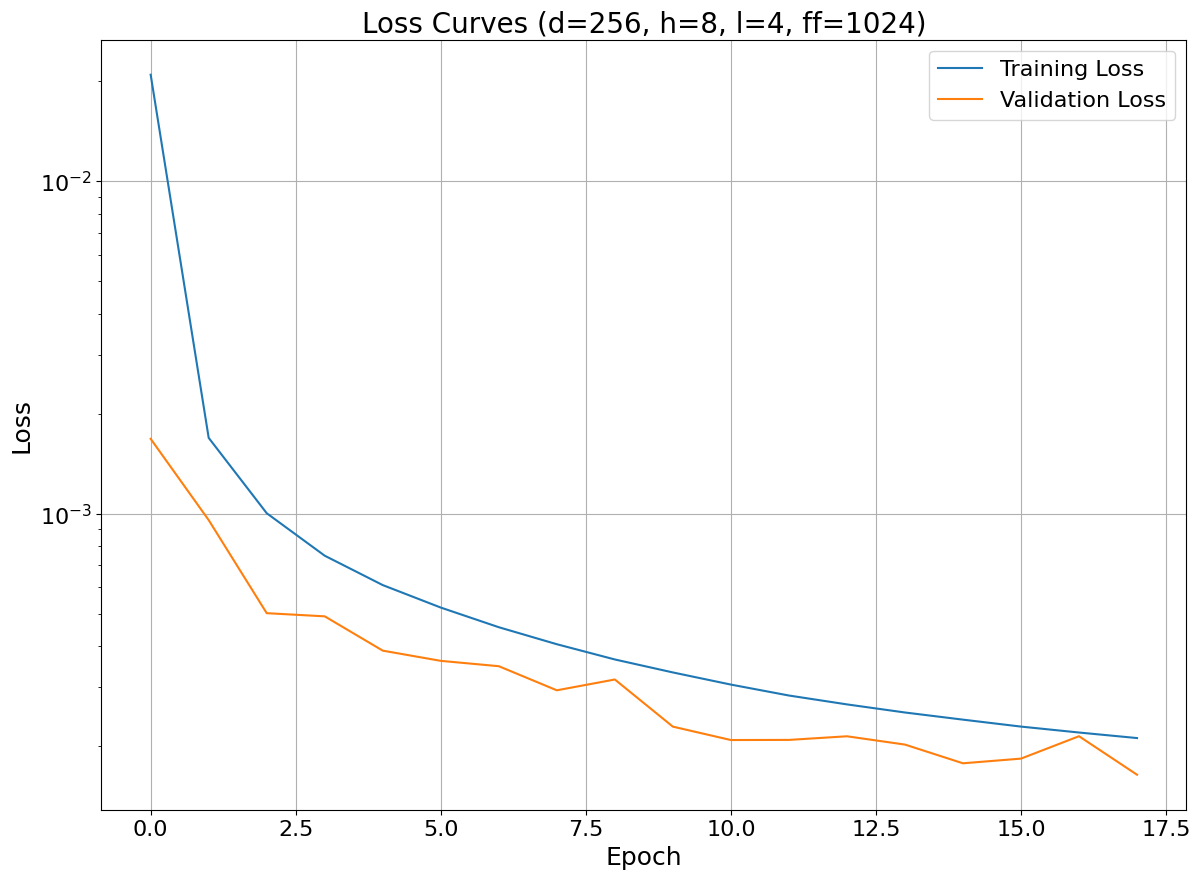


Training curve saved to c:\Users\truok\projects\metabolic-NN\pics\AB_1M_d256_h8_l4_ff1024\AB_union_evaluation\20260917T150631340189Z\figures\AB_1M_d256_h8_l4_ff1024_loss_curves.png


In [6]:
checkpoint_plot_data = torch.load(CHECKPOINT, map_location="cpu", weights_only=False)
train_losses = checkpoint_plot_data.get("train_losses", [])
validation_losses = checkpoint_plot_data.get("test_losses", [])
del checkpoint_plot_data
if len(train_losses) and len(validation_losses):
    plot_loss_curves(train_losses, validation_losses,
        architecture["d_model"], architecture["n_heads"], architecture["n_layers"], architecture["d_ff"],
        save_path=str(pic_dir / f"{model_name}_loss_curves.png"))
else:
    print("Checkpoint has no saved loss history; loss plot skipped.")


,R2,Pearson_r2,MAE,RMSE,NE
0,0.998179,0.999489,0.005693,0.007438,0.020441


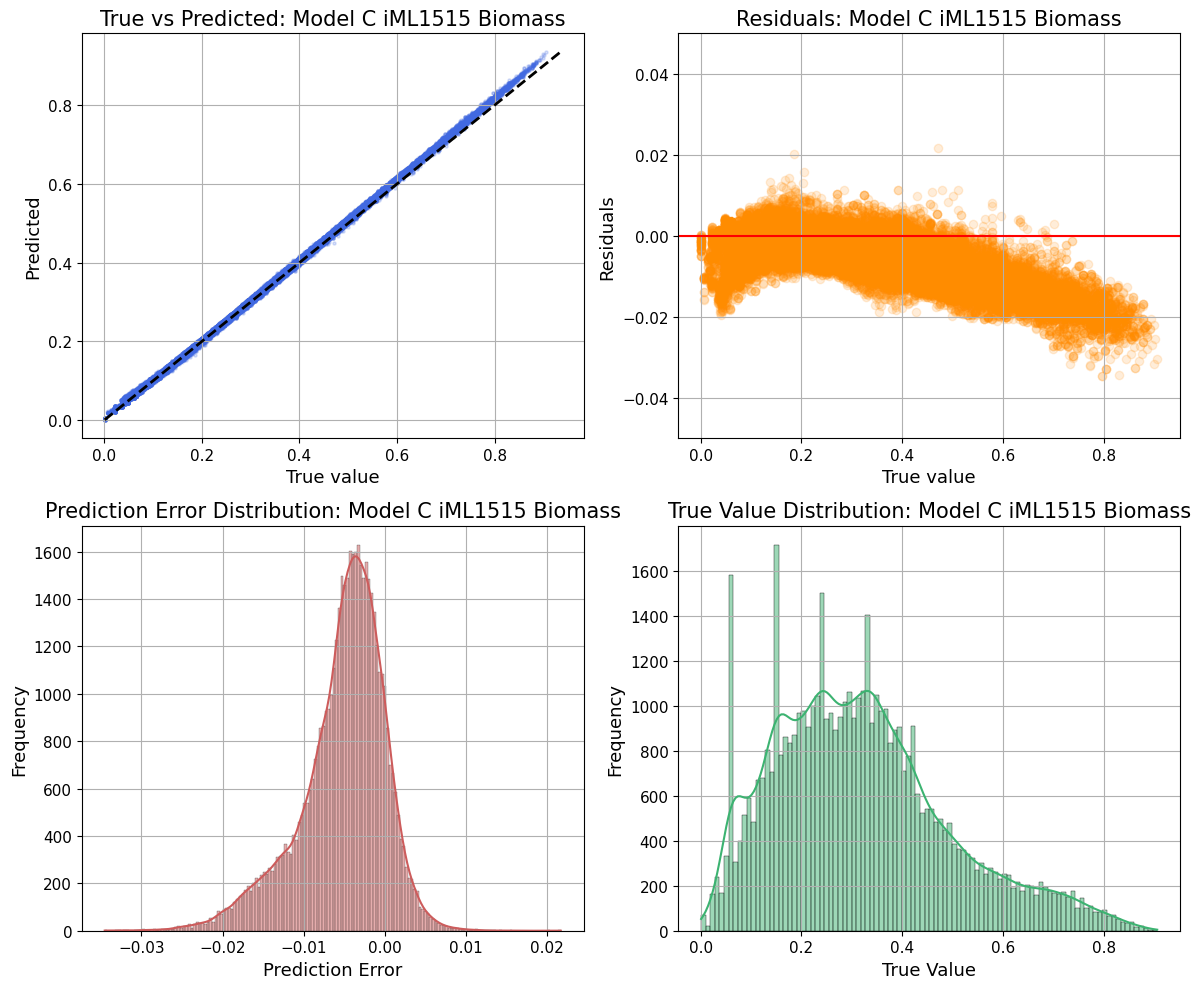

In [7]:
biomass_diagnostic = None
if BIOMASS_TEST_PATH is None or not Path(BIOMASS_TEST_PATH).is_file():
    print("Biomass diagnostic skipped: set BIOMASS_TEST_PATH to an independent simulated test CSV.")
else:
    if Path(BIOMASS_TEST_PATH).resolve() == Path(str(training_info.get("dataset", ""))).resolve():
        raise ValueError("Biomass diagnostics require held-out data, not the training CSV.")
    header = pd.read_csv(BIOMASS_TEST_PATH, nrows=0).columns.tolist()
    if [name for name in header if name.endswith("_flux")] != output_names:
        raise ValueError("Biomass test output order differs from the checkpoint.")
    if [name for name in header if not name.endswith("_flux")] != input_names:
        raise ValueError("Biomass test input order differs from the checkpoint.")
    biomass_token = f"{ev.OBJECTIVE}_flux"
    biomass_index = output_names.index(biomass_token)
    injection = [output_names.index(f"{name}_flux") for name in input_names]
    biomass_truth, biomass_prediction = [], []
    reservoir.eval()
    with torch.inference_mode():
        for frame in pd.read_csv(BIOMASS_TEST_PATH, usecols=input_names + [biomass_token], chunksize=128):
            ev.finite_frame(frame, "Biomass test data")
            medium = frame[input_names].to_numpy(np.float32)
            biomass_truth.extend(frame[biomass_token].to_numpy(float))
            for start in range(0, len(frame), BIOMASS_BATCH_SIZE):
                values = torch.as_tensor(medium[start:start + BIOMASS_BATCH_SIZE], device=DEVICE)
                c = torch.zeros(len(values), len(output_names), 1, device=DEVICE)
                c[:, injection, 0] = values
                predicted, _ = reservoir(c, output_subset=None)
                biomass_prediction.extend(predicted[:, biomass_index, -1].cpu().numpy())
    biomass_diagnostic = pd.DataFrame({"truth": biomass_truth, "prediction": biomass_prediction})
    display(pd.DataFrame([ev.metrics(biomass_truth, biomass_prediction)]))
    biomass_diagnostic.to_csv(run_dir / "biomass_diagnostic.csv", index=False)
    plot_diagnostics_2x2(biomass_truth, biomass_prediction, biomass_token,
        save_path=str(pic_dir / f"{model_name}_biomass_diagnostic.png"))


## Glycolysis post-layer token embeddings

Two views following the original AMN_MINN notebook: individual reaction colors and a rainbow ordered by nutrient-context similarity. Both use the first 4,000 rows of the independent simulated test CSV, perplexity 40 and seed 10. Reaction centers and labels retain the original styling. Embeddings come after the final transformer layer using glycolysis plus injected input tokens, matching the original subset-forward visualization. These are qualitative views, separate from full-vocabulary flux evaluation.


In [8]:
from sklearn.manifold import TSNE
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

def plot_reaction_subset_tsne(
    model,
    token_names,
    X_context,
    reaction_subset,
    *,
    subset_name=None,
    n_samples=8000,
    perplexity=40.0,
    batch_size=128,
    random_state=10,
    annotate=True,
    annotate_fontsize=15,
    save_path=None,
    print_colors=True,
    sample_color_mode="reaction",  # "reaction", "gray", "rainbow", "viridis", "plasma", or "coolwarm"
    show_pre_embeddings=False,
    return_data=False,
):
    """
    Plot post-layer FluxTransformer token embeddings for a selected reaction subset.

    reaction_subset can be either:
      - a key from pathway_reaction_lists, such as "glycolysis_reactions"
      - a list of reaction IDs, such as glycolysis_reactions
      - a list of flux token names ending in "_flux"

    Each reaction in the subset receives its own color before embeddings are collected.
    With sample_color_mode="gray", all subset-reaction points are plotted in gray.
    With sample_color_mode="rainbow" or another colormap, points are colored by
    nutrient-context similarity while reaction colors are kept only for centers.
    If show_pre_embeddings=True, initial token embeddings are included in the
    same t-SNE fit and plotted as black dots.
    """
    device = next(model.parameters()).device
    model.eval()

    V = int(model.vocab_size)
    if len(token_names) != V:
        raise ValueError(f"len(token_names)={len(token_names)} but model.vocab_size={V}.")

    if isinstance(reaction_subset, str):
        if reaction_subset in pathway_reaction_lists:
            reaction_ids = list(pathway_reaction_lists[reaction_subset])
            subset_label = subset_name or reaction_subset
        else:
            reaction_ids = [reaction_subset]
            subset_label = subset_name or reaction_subset
    else:
        reaction_ids = list(reaction_subset)
        subset_label = subset_name or "reaction subset"

    reaction_ids = list(dict.fromkeys(str(r) for r in reaction_ids))
    if not reaction_ids:
        raise ValueError("reaction_subset is empty.")

    token_lookup = {name: idx for idx, name in enumerate(token_names)}
    selected_token_names = []
    display_reaction_ids = []
    missing = []
    for reaction_id in reaction_ids:
        base_id = reaction_id[:-5] if reaction_id.endswith("_flux") else reaction_id
        candidates = (reaction_id, f"{base_id}_flux", base_id)
        token_name = next((candidate for candidate in candidates if candidate in token_lookup), None)
        if token_name is None:
            missing.append(reaction_id)
            continue
        selected_token_names.append(token_name)
        display_reaction_ids.append(token_name[:-5] if token_name.endswith("_flux") else token_name)

    if missing:
        raise ValueError(f"These reactions are not present in token_names: {missing}")

    token_indices = [token_lookup[name] for name in selected_token_names]
    n_tok = len(token_indices)
    colors = plt.cm.nipy_spectral(np.linspace(0.05, 0.95, n_tok))
    from matplotlib.colors import to_hex

    reaction_colors = {
        reaction_id: color
        for reaction_id, color in zip(display_reaction_ids, colors)
    }
    reaction_color_hex = {
        reaction_id: to_hex(color)
        for reaction_id, color in reaction_colors.items()
    }

    mode = str(sample_color_mode).strip().lower()
    allowed_modes = {"reaction", "gray", "rainbow", "viridis", "plasma", "coolwarm"}
    if mode not in allowed_modes:
        raise ValueError("sample_color_mode must be one of: reaction, gray, rainbow, viridis, plasma, coolwarm.")
    use_gray = mode == "gray"
    use_sample_colormap = mode in {"rainbow", "viridis", "plasma", "coolwarm"}

    if print_colors and mode == "reaction":
        print("Reaction colors:")
        for reaction_id in display_reaction_ids:
            print(f"  {reaction_id}: {reaction_color_hex[reaction_id]}")

    if not torch.is_tensor(X_context):
        X_context = torch.tensor(X_context, dtype=torch.float32)
    if X_context.dim() != 2 or X_context.size(1) != V:
        raise ValueError(f"X_context must have shape (N, {V}). Got {tuple(X_context.shape)}")

    N = min(int(n_samples), int(X_context.size(0)))
    if N <= 0:
        raise ValueError("n_samples selects zero contexts.")

    X_norm_cond = None
    if use_sample_colormap:
        X_cond = X_context[:N]
        if torch.is_tensor(X_cond):
            X_cond = X_cond.detach().cpu().numpy()
        else:
            X_cond = np.asarray(X_cond, dtype=np.float32)

        if hasattr(model, "input_token_indices") and model.input_token_indices is not None:
            cond_idx = model.input_token_indices.detach().cpu().numpy().astype(np.int64)
            cond_idx = cond_idx[(cond_idx >= 0) & (cond_idx < X_cond.shape[1])]
            if cond_idx.size > 0:
                X_cond = X_cond[:, cond_idx]

        X_cond = X_cond.astype(np.float64, copy=False)
        mu = np.nanmean(X_cond, axis=0, keepdims=True)
        sigma = np.nanstd(X_cond, axis=0, keepdims=True)
        sigma[sigma < 1e-12] = 1.0
        X_norm_cond = (X_cond - mu) / sigma
        X_norm_cond = np.nan_to_num(X_norm_cond, nan=0.0, posinf=0.0, neginf=0.0)

    token_indices_tensor = torch.tensor(token_indices, dtype=torch.long, device=device)
    pos_in_selected = None
    all_embeddings = []
    token_id_labels = []
    sample_id_labels = []

    with torch.no_grad():
        for start in range(0, N, batch_size):
            stop = min(start + batch_size, N)
            batch_context = X_context[start:stop].to(device).unsqueeze(-1)
            x, selected_indices = model(
                batch_context,
                output_subset=token_indices_tensor,
                return_embedding=True,
            )

            if pos_in_selected is None:
                selected_list = [int(v) for v in selected_indices.detach().cpu().tolist()]
                pos_by_token = {token_idx: pos for pos, token_idx in enumerate(selected_list)}
                missing_selected = [idx for idx in token_indices if idx not in pos_by_token]
                if missing_selected:
                    missing_names = [token_names[idx] for idx in missing_selected]
                    raise RuntimeError(f"Requested tokens were not returned by the model: {missing_names}")
                pos_in_selected = torch.tensor(
                    [pos_by_token[idx] for idx in token_indices],
                    dtype=torch.long,
                    device=device,
                )

            keep_x = x.index_select(1, pos_in_selected)
            batch_size_actual = stop - start
            all_embeddings.append(keep_x.detach().cpu())
            token_id_labels.append(np.tile(np.arange(n_tok, dtype=np.int64), batch_size_actual))
            sample_id_labels.append(np.repeat(np.arange(start, stop, dtype=np.int64), n_tok))

    all_embeddings = torch.cat(all_embeddings, dim=0)
    token_id_labels = np.concatenate(token_id_labels, axis=0)
    sample_id_labels = np.concatenate(sample_id_labels, axis=0)
    embeddings_flat = all_embeddings.reshape(-1, all_embeddings.shape[-1]).numpy()
    n_points = embeddings_flat.shape[0]
    if n_points < 3:
        raise ValueError(f"Need at least 3 embedding points for t-SNE, got {n_points}.")

    pre_embeddings = None
    embeddings_for_tsne = embeddings_flat
    if show_pre_embeddings:
        if not hasattr(model, "input_embedding"):
            raise AttributeError("show_pre_embeddings=True requires model.input_embedding.")
        with torch.no_grad():
            pre_embeddings = model.input_embedding(token_indices_tensor).detach().cpu().numpy()
        embeddings_for_tsne = np.concatenate([embeddings_flat, pre_embeddings], axis=0)

    n_points_joint = embeddings_for_tsne.shape[0]
    if perplexity >= n_points_joint:
        new_perplexity = max(1.0, min(30.0, (n_points_joint - 1) / 3.0))
        print(f"[plot_reaction_subset_tsne] Adjusting perplexity {perplexity} -> {new_perplexity:.2f} (n_points={n_points_joint})")
        perplexity = float(new_perplexity)

    emb2d_joint = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=random_state,
        init="pca",
    ).fit_transform(embeddings_for_tsne)
    emb2d = emb2d_joint[:n_points]
    pre_emb2d = emb2d_joint[n_points:] if show_pre_embeddings else None

    base_s = 10.0
    base_alpha = 0.22
    center_s = 36.0
    if n_tok <= 20:
        base_s = 30.0
        base_alpha = 0.38
        center_s = 72.0
    if n_tok <= 10:
        base_s = 36.0
        base_alpha = 0.48
        center_s = 86.0

    rainbow_order = np.arange(N, dtype=np.int64)
    if use_sample_colormap and X_norm_cond is not None and N > 1:
        start_idx = int(np.argmin(np.sum((X_norm_cond - X_norm_cond.mean(axis=0, keepdims=True)) ** 2, axis=1)))
        order = np.empty(N, dtype=np.int64)
        unvisited = np.ones(N, dtype=bool)
        current = start_idx
        for order_pos in range(N):
            order[order_pos] = current
            unvisited[current] = False
            if order_pos == N - 1:
                break
            remaining = np.flatnonzero(unvisited)
            distances = np.sum((X_norm_cond[remaining] - X_norm_cond[current]) ** 2, axis=1)
            current = int(remaining[np.argmin(distances)])
        rainbow_order = order

    discrete_cmap = ListedColormap(colors)
    plt.figure(figsize=(16, 12))
    if use_gray:
        plt.scatter(
            emb2d[:, 0],
            emb2d[:, 1],
            c="#b5b5b5",
            alpha=base_alpha,
            s=base_s,
            edgecolors="none",
        )
    elif use_sample_colormap:
        if N > 1:
            sample_rank = np.empty(N, dtype=np.int64)
            sample_rank[rainbow_order] = np.arange(N, dtype=np.int64)
            sample_norm = sample_rank[sample_id_labels].astype(np.float64) / float(N - 1)
        else:
            sample_norm = np.zeros_like(sample_id_labels, dtype=np.float64)
        cmap = plt.cm.rainbow_r if mode == "rainbow" else plt.get_cmap(mode)
        point_colors = cmap(sample_norm)
        plt.scatter(
            emb2d[:, 0],
            emb2d[:, 1],
            c=point_colors,
            alpha=max(base_alpha, 0.70),
            s=base_s,
            edgecolors="none",
        )
    else:
        plt.scatter(
            emb2d[:, 0],
            emb2d[:, 1],
            c=token_id_labels,
            cmap=discrete_cmap,
            vmin=0,
            vmax=max(1, n_tok - 1),
            alpha=base_alpha,
            s=base_s,
            edgecolors="none",
        )

    centers = []
    for local_idx in range(n_tok):
        mask = token_id_labels == local_idx
        if np.any(mask):
            centers.append((local_idx, np.median(emb2d[mask], axis=0)))

    for local_idx, center in centers:
        label = display_reaction_ids[local_idx]
        center_color = "#8a8a8a" if use_gray else colors[local_idx]
        plt.scatter(
            center[0],
            center[1],
            s=center_s,
            marker="o",
            color=center_color,
            edgecolor="black",
            linewidth=0.6,
            zorder=3,
        )
        if annotate:
            plt.annotate(
                label,
                center,
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=annotate_fontsize,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8),
            )

    if show_pre_embeddings:
        plt.scatter(
            pre_emb2d[:, 0],
            pre_emb2d[:, 1],
            c="black",
            alpha=0.95,
            s=max(center_s, 120.0),
            edgecolors="white",
            linewidths=0.8,
            zorder=4,
            label="Pre-token embeddings",
        )
        print(f"Pre-embedding points plotted: {len(pre_emb2d)}")

    if mode == "reaction":
        legend_handles = [
            mpatches.Patch(color=colors[i], label=display_reaction_ids[i])
            for i in range(n_tok)
        ]
        reaction_legend = plt.legend(
            handles=legend_handles,
            title="Reaction",
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
            fontsize=13,
            title_fontsize=14,
            frameon=False,
        )
        if show_pre_embeddings:
            pre_handle = plt.Line2D(
                [0], [0], marker="o", color="none", label="Pre-token embeddings",
                markerfacecolor="black", markeredgecolor="white", markeredgewidth=0.8,
                markersize=9,
            )
            plt.gca().add_artist(reaction_legend)
            plt.legend(handles=[pre_handle], loc="upper right", fontsize=15, frameon=True)
    elif show_pre_embeddings:
        plt.legend(loc="upper right", fontsize=15, frameon=True)
    plt.title(
        f"Post-layer Token Embeddings (t-SNE): {subset_label}\n"
        f"(n_contexts={N}, n_tokens={n_tok})",
        fontsize=26,
    )
    plt.xlabel("t-SNE 1", fontsize=22)
    plt.ylabel("t-SNE 2", fontsize=22)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(alpha=0.1)
    plt.tight_layout()

    if save_path:
        save_dir = os.path.dirname(str(save_path))
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"Plot saved to {save_path}")
    plt.show()
    plt.close()

    if return_data:
        return {
            "embedding_2d": emb2d,
            "token_id_labels": token_id_labels,
            "reaction_ids": display_reaction_ids,
            "reaction_colors": reaction_color_hex,
            "sample_id_labels": sample_id_labels,
            "sample_color_mode": mode,
            "pre_embedding_2d": pre_emb2d,
        }


In [9]:
# Match the original reaction list, extraction and plotting settings.
glycolysis_reactions = [
    "GLCptspp", "GLCt2pp", "HEX1", "PGI", "PFK", "FBA", "TPI",
    "GAPD", "PGK", "PGM", "ENO", "PYK", "PPS", "FBP",
]
pathway_reaction_lists = {"glycolysis_reactions": glycolysis_reactions}
TSNE_SETTINGS = dict(n_samples=4000, perplexity=40.0, batch_size=128,
                     random_state=10, annotate=True, annotate_fontsize=16)
TSNE_CONTEXT_PATH = BIOMASS_TEST_PATH
if TSNE_CONTEXT_PATH is None or not Path(TSNE_CONTEXT_PATH).is_file():
    raise FileNotFoundError("Set BIOMASS_TEST_PATH to the A-union-B simulated test CSV for t-SNE.")
if Path(TSNE_CONTEXT_PATH).resolve() == Path(str(training_info.get("dataset", ""))).resolve():
    raise ValueError("Use independent simulated test contexts for t-SNE.")
tsne_header = pd.read_csv(TSNE_CONTEXT_PATH, nrows=0).columns.tolist()
if [c for c in tsne_header if c.endswith("_flux")] != output_names:
    raise ValueError("t-SNE test output order differs from the checkpoint.")
if [c for c in tsne_header if not c.endswith("_flux")] != input_names:
    raise ValueError("t-SNE test input order differs from the checkpoint.")
# Read only medium inputs; no full flux target matrix or training is needed.
tsne_frame = pd.read_csv(TSNE_CONTEXT_PATH, usecols=input_names,
                         nrows=TSNE_SETTINGS["n_samples"])
ev.finite_frame(tsne_frame, "t-SNE contexts")
tsne_context = torch.zeros(len(tsne_frame), len(output_names), dtype=torch.float32)
tsne_injection = [output_names.index(f"{name}_flux") for name in input_names]
tsne_context[:, tsne_injection] = torch.from_numpy(tsne_frame[input_names].to_numpy(np.float32))
ev.save_json(run_dir / "tsne_settings.json", {
    **TSNE_SETTINGS, "context_path": str(TSNE_CONTEXT_PATH),
    "context_sha256": ev.file_hash(TSNE_CONTEXT_PATH),
    "context_rows": list(range(len(tsne_frame))), "reactions": glycolysis_reactions,
    "extraction": "post-final-layer; glycolysis plus injected input tokens",
    "color_modes": ["reaction", "rainbow"],
})


Reaction colors:
  GLCptspp: #700080
  GLCt2pp: #58009f
  HEX1: #0000d1
  PGI: #007add
  PFK: #00a2c3
  FBA: #00aa8b
  TPI: #00a400
  GAPD: #00d200
  PGK: #0fff00
  PGM: #d4f700
  ENO: #fdcf00
  PYK: #ff7500
  PPS: #e90000
  FBP: #cc0c0c
Plot saved to c:\Users\truok\projects\metabolic-NN\pics\AB_1M_d256_h8_l4_ff1024\AB_union_evaluation\20260917T150631340189Z\figures\AB_1M_d256_h8_l4_ff1024_tsne_glycolysis_reaction.png


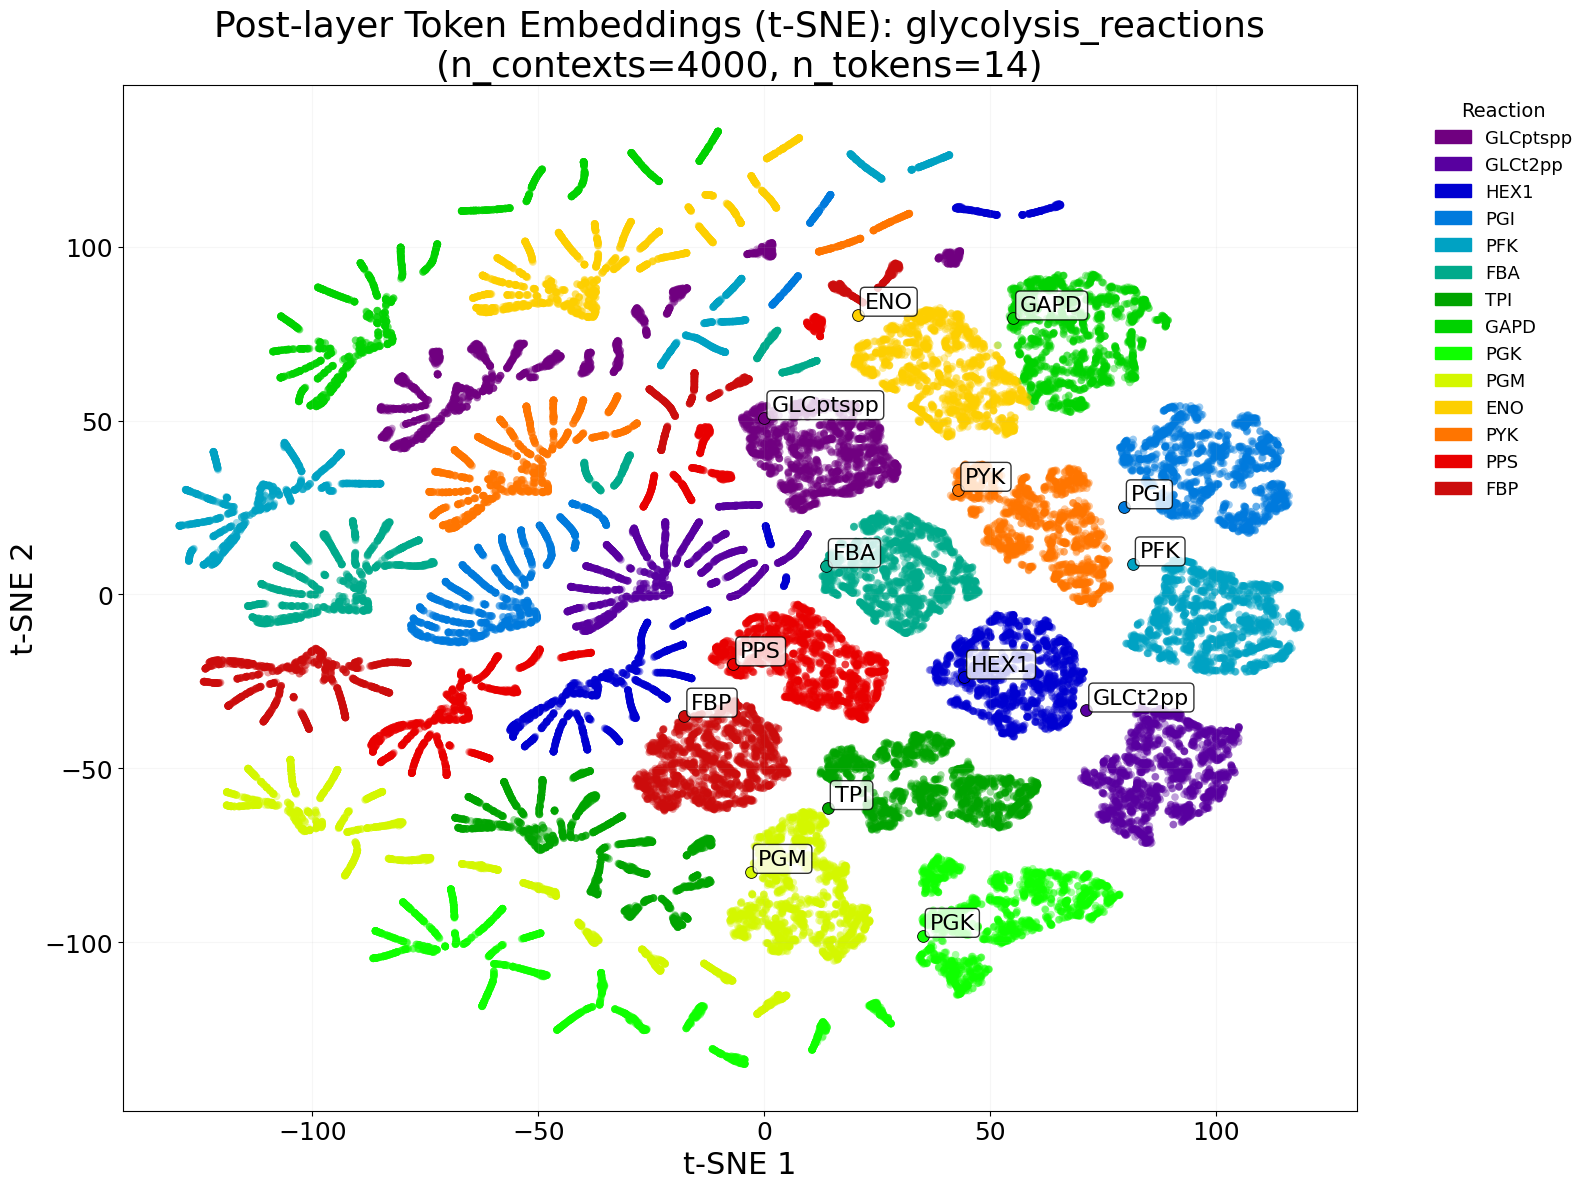

In [10]:
plot_reaction_subset_tsne(
    reservoir, output_names, tsne_context, glycolysis_reactions,
    subset_name="glycolysis_reactions", **TSNE_SETTINGS,
    sample_color_mode="reaction", show_pre_embeddings=False,
    save_path=str(pic_dir / f"{model_name}_tsne_glycolysis_reaction.png"),
)


Plot saved to c:\Users\truok\projects\metabolic-NN\pics\AB_1M_d256_h8_l4_ff1024\AB_union_evaluation\20260917T150631340189Z\figures\AB_1M_d256_h8_l4_ff1024_tsne_glycolysis_rainbow.png


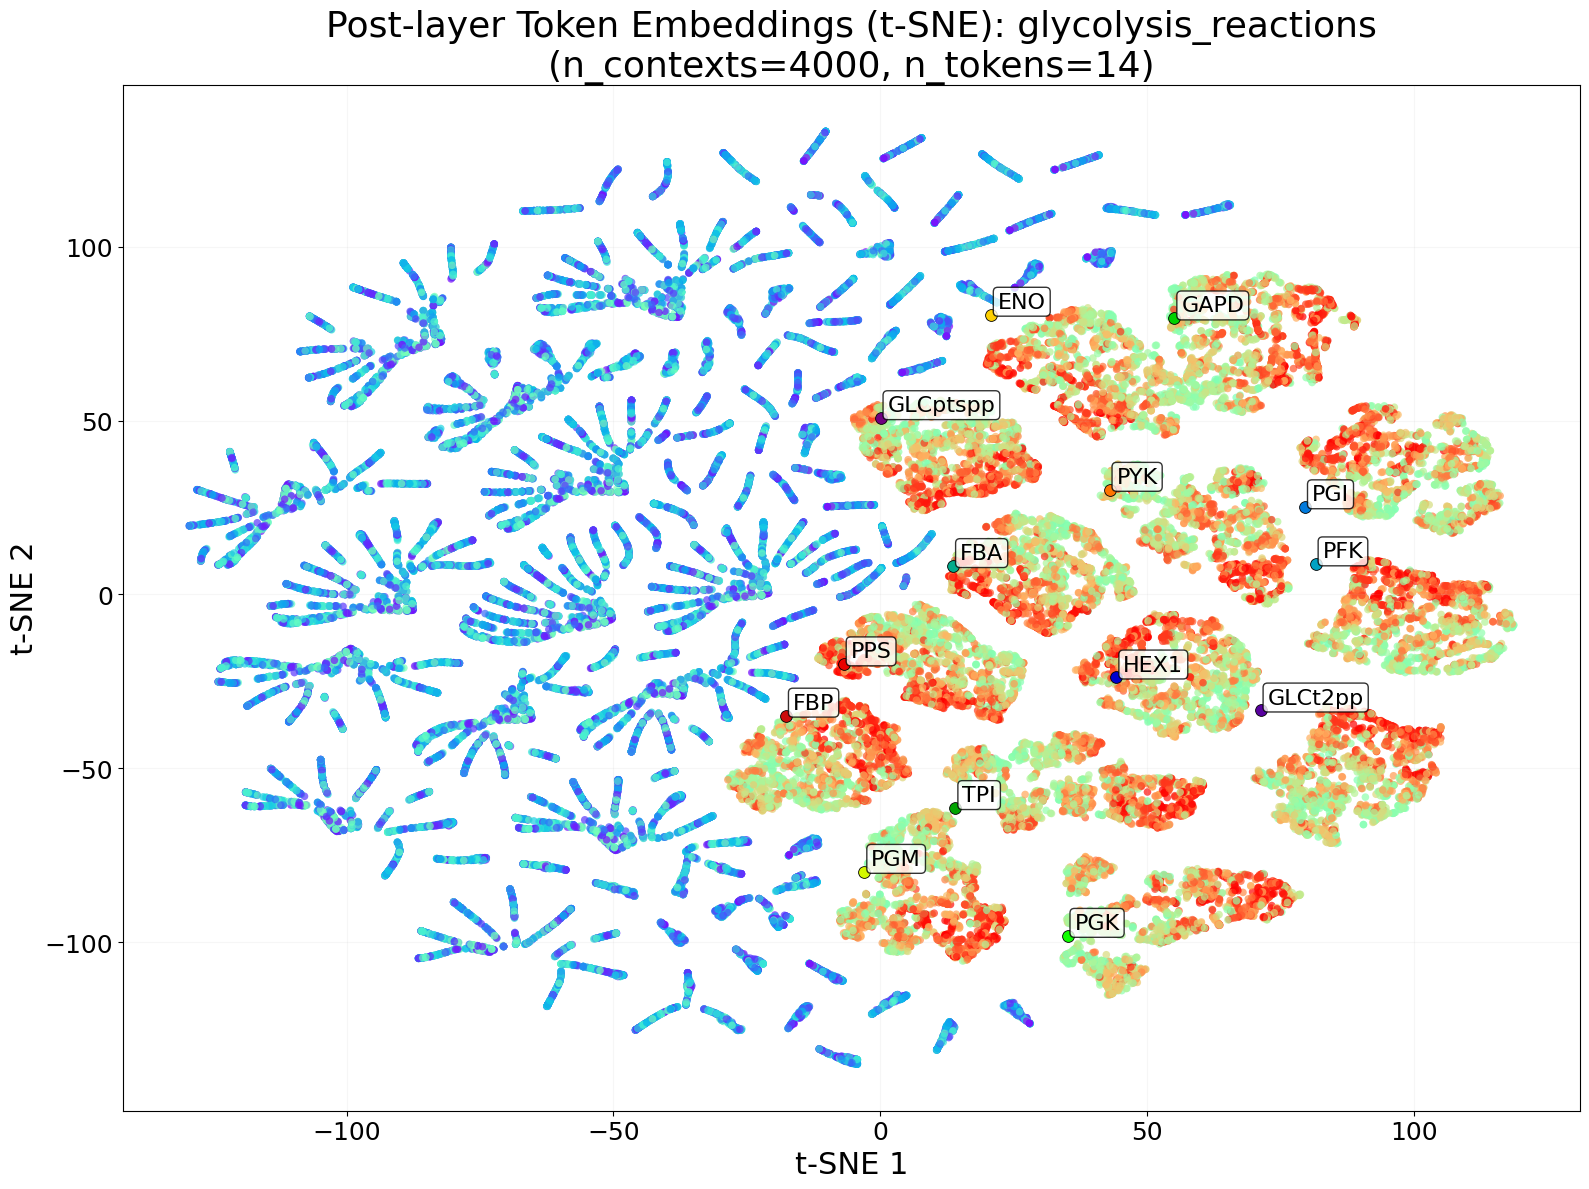

In [11]:
plot_reaction_subset_tsne(
    reservoir, output_names, tsne_context, glycolysis_reactions,
    subset_name="glycolysis_reactions", **TSNE_SETTINGS,
    sample_color_mode="rainbow", show_pre_embeddings=False,
    save_path=str(pic_dir / f"{model_name}_tsne_glycolysis_rainbow.png"),
)


## Independent simulated-data fidelity

A and B are scored separately, plus an equally weighted pooled score. Full-output inference is mandatory. The helper streams all rows, exports per-flux error/activity and per-row mass-balance/bound diagnostics, and checks objective agreement on the configured subset. A's CO2/acetate uptake semantics and B's secretion-cap semantics remain distinct. The generation commands are part of the recorded provenance.

In [12]:
if RUN_SIMULATED:
    for spec in SIMULATED.values():
        training_path = Path(str(training_info.get("dataset", "")))
        if Path(spec["path"]).resolve() == training_path.resolve():
            raise ValueError("Simulated evaluation path points at the training dataset.")
    simulated_summary = ev.simulated_fidelity(reservoir, input_names, output_names,
        SIMULATED, XML_PATH, run_dir / "simulated", batch_size=SIM_BATCH_SIZE,
        objective_samples=OBJECTIVE_CHECK_SAMPLES, fraction=0.999)
    display(simulated_summary)
else:
    print("Optional full A/B fidelity analysis skipped.")


Optional full A/B fidelity analysis skipped.


## AMN: prepare A-union-B media

The 110 media use the A-regime basal inputs (including CO2) at 10, fixed glycerol/amino acids at 2.2, and absent glucose/ethanol/cobalamin at zero. These model-specific bounds follow the AB-union generator; the evaluation protocol matches C. A masked sigmoid prior predicts the ten carbon rates and oxygen, in checkpoint input order. Carbon rates range from 0 to 2.2; oxygen from 0 to 10. Experimental SD is joined by medium composition and checked against measured growth.


In [13]:
if RUN_AMN:
    amn_data = ev.load_amn(AMN_DIR, input_names=input_names, model_family=MODEL_FAMILY,
                           feature_order="checkpoint")
    display(pd.DataFrame({"input": list(amn_data["fixed"]), "fixed_value": list(amn_data["fixed"].values())}))
    print("AMN features:", amn_data["features"])
    print("AMN shape:", amn_data["X"].shape)
    ev.save_json(run_dir / "amn_schema.json", {"features": amn_data["features"],
        "targets": amn_data["targets"], "sample_ids": amn_data["ids"].tolist(), "fixed": amn_data["fixed"]})


,input,fixed_value
0,EX_glc__D_e,0.0
1,EX_o2_e,0.0
2,EX_co2_e,10.0
3,EX_etoh_e,0.0
4,EX_ac_e,0.0
5,EX_pi_e,10.0
6,EX_fe3_e,10.0
7,EX_h_e,10.0
8,EX_mn2_e,10.0
9,EX_fe2_e,10.0


AMN features: ['EX_o2_e', 'EX_ac_e', 'EX_rib__D_e', 'EX_malt_e', 'EX_melib_e', 'EX_tre_e', 'EX_fru_e', 'EX_gal_e', 'EX_lac__D_e', 'EX_succ_e', 'EX_pyr_e']
AMN shape: (110, 11)


### Train the AMN MLP with the original repeated-CV protocol

Match `ecoli_iML1515_AMN_MINN_model_testing_trial.ipynb`: ten folds stratified by carbon count, repeated with seeds 10/11/12; training seed 10 for every fold. Train on 99 media and select the best checkpoint using the 11 held-out media (100 epochs maximum, patience 15), then score that checkpoint without refitting. Preserve checkpoint-order features, AdamW, Huber delta 0.03, no gradient clipping, training batch 1 and validation batch 2. This reproduces the historical protocol; held-out targets participate in epoch selection. This matches the C notebook protocol; rerun with the AB-union checkpoint to obtain AB-union results.

In [14]:
if RUN_AMN:
    amn_result = ev.run_amn(reservoir, output_names, amn_data, AMN_SETTINGS, run_dir / "amn")
    display(amn_result["summary"])
    display(amn_result["summary"].drop(columns="repeat").agg(["mean", lambda x: x.std(ddof=0)]))


AMN repeat 10, fold 1: legacy_outer_early_stopping, selected epoch 7
AMN repeat 10, fold 2: legacy_outer_early_stopping, selected epoch 15
AMN repeat 10, fold 3: legacy_outer_early_stopping, selected epoch 15
AMN repeat 10, fold 4: legacy_outer_early_stopping, selected epoch 46
AMN repeat 10, fold 5: legacy_outer_early_stopping, selected epoch 4
AMN repeat 10, fold 6: legacy_outer_early_stopping, selected epoch 4
AMN repeat 10, fold 7: legacy_outer_early_stopping, selected epoch 9
AMN repeat 10, fold 8: legacy_outer_early_stopping, selected epoch 23
AMN repeat 10, fold 9: legacy_outer_early_stopping, selected epoch 39
AMN repeat 10, fold 10: legacy_outer_early_stopping, selected epoch 33
AMN repeat 11, fold 1: legacy_outer_early_stopping, selected epoch 10
AMN repeat 11, fold 2: legacy_outer_early_stopping, selected epoch 21
AMN repeat 11, fold 3: legacy_outer_early_stopping, selected epoch 12
AMN repeat 11, fold 4: legacy_outer_early_stopping, selected epoch 9
AMN repeat 11, fold 5: l

,repeat,R2,Pearson_r2,MAE,RMSE,NE
0,10,0.869013,0.869250,0.023403,0.030519,0.123130
1,11,0.852395,0.853007,0.024880,0.032397,0.130707
2,12,0.860092,0.860233,0.025523,0.031541,0.127254


,R2,Pearson_r2,MAE,RMSE,NE
mean,0.860500,0.860830,0.024602,0.031486,0.127030
<lambda>,0.006791,0.006645,0.000888,0.000768,0.003098


### AMN growth errors and uncertainty

Model C-style reporting: average OOF predictions per medium, then compute R2, MAE and RMSE across those means. Report population SD of per-repeat metrics separately. Orange horizontal bars show experimental SD; orange vertical bars show prediction SD across repeats (ddof=1). This spread is not a calibrated prediction interval.


,Metric,OOF score,SD across repeats
0,R2,0.874726,0.006791
1,MAE,0.023454,0.000888
2,RMSE,0.029846,0.000768


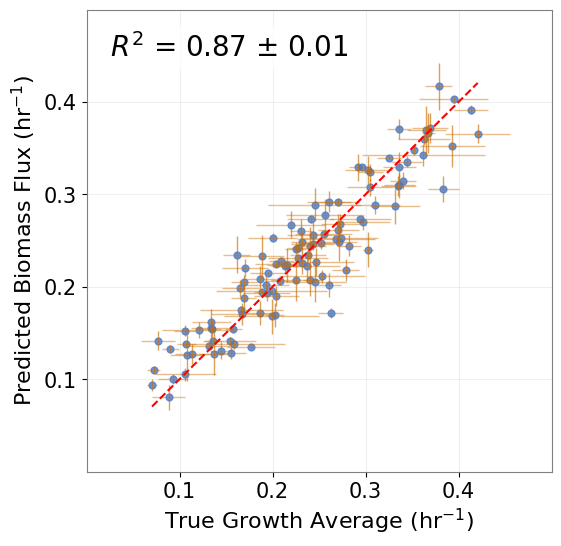

,repeat,carbon_count,R2,Pearson_r2,MAE,RMSE,NE
0,10,1,0.564742,0.728734,0.025938,0.031713,0.223077
1,10,2,0.848875,0.857282,0.021803,0.028191,0.131431
2,10,3,0.795646,0.803105,0.023288,0.031794,0.134111
3,10,4,0.854226,0.854743,0.023684,0.030029,0.103189
4,11,1,0.686002,0.792366,0.022148,0.026936,0.189471
5,11,2,0.889240,0.898958,0.020718,0.024134,0.112517
6,11,3,0.752373,0.757230,0.026746,0.034998,0.147629
7,11,4,0.807814,0.811689,0.025778,0.034480,0.118482
8,12,1,0.560044,0.644834,0.027658,0.031884,0.224277
9,12,2,0.822950,0.825122,0.026723,0.030513,0.142258


In [15]:
# Refresh an older kernel import without discarding trained results.
if not hasattr(ev, "summarize_amn_oof"):
    from importlib import reload
    ev = reload(ev)

if amn_result is not None:
    oof = amn_result["oof"]
    means, amn_scores, amn_spread = ev.summarize_amn_oof(
        oof, len(amn_data["ids"]), AMN_SETTINGS["split_seeds"])
    oof_true_cv = means.truth.to_numpy()
    oof_pred_cv = means.prediction.to_numpy()
    oof_std_cv = amn_data["growth_std"][means.index]
    oof_pred_seed_std_cv = means.prediction_std.to_numpy()
    r2_oof, r2_oof_std = amn_scores["R2"], amn_spread["R2"]
    line_min_cv = float(max(0.0, min(oof_true_cv.min(), oof_pred_cv.min())))
    line_max_cv = float(min(0.5, max(oof_true_cv.max(), oof_pred_cv.max())))

    def format_r2_with_std(r2_value, r2_std):
        std_precision = 3 if abs(float(r2_std)) < 0.005 else 2
        return f"$R^2$ = {r2_value:.2f} $\\pm$ {r2_std:.{std_precision}f}"

    amn_metric_summary = pd.DataFrame([
        {"Metric": key, "OOF score": amn_scores[key], "SD across repeats": amn_spread[key]}
        for key in ("R2", "MAE", "RMSE")])
    display(amn_metric_summary)
    amn_metric_summary.to_csv(run_dir / "amn/aggregated_oof_metrics.csv", index=False)

    plt.figure(figsize=(6, 6))
    plt.hlines(
        y=oof_pred_cv,
        xmin=oof_true_cv - oof_std_cv,
        xmax=oof_true_cv + oof_std_cv,
        colors="#CC6E00",
        alpha=0.45,
        linewidth=1.0,
    )
    plt.vlines(
        x=oof_true_cv,
        ymin=oof_pred_cv - oof_pred_seed_std_cv,
        ymax=oof_pred_cv + oof_pred_seed_std_cv,
        colors="#CC6E00",
        alpha=0.65,
        linewidth=1.0,
    )
    plt.scatter(oof_true_cv, oof_pred_cv, alpha=0.78, s=24, c="#3F7BD9")
    plt.plot([line_min_cv, line_max_cv], [line_min_cv, line_max_cv], "r--", lw=1.5)
    plt.xlabel(r"True Growth Average (hr$^{-1}$)", fontsize=16)
    plt.ylabel(r"Predicted Biomass Flux (hr$^{-1}$)", fontsize=16)
    #plt.title("Out-of-Fold True vs Predicted", fontsize=16)
    plt.xlim(0.0, 0.5)
    plt.ylim(0.0, 0.5)
    plt.text(0.05, 0.95, format_r2_with_std(r2_oof, r2_oof_std), transform=plt.gca().transAxes,
             ha="left", va="top", fontsize=20,
             bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75))
    plt.xticks(np.arange(0.1, 0.5, 0.1), fontsize=15)
    plt.yticks(np.arange(0.1, 0.5, 0.1), fontsize=15)
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_color("gray")
    plt.grid(alpha=0.2)
    plt.savefig(pic_dir / f"{model_name}_amn_growth.png", dpi=300, bbox_inches="tight")
    plt.show()
    carbon_metrics = pd.DataFrame([{"repeat": repeat, "carbon_count": count, **ev.metrics(part.truth, part.prediction)}
        for (repeat, count), part in oof.groupby(["repeat", "carbon_count"])])
    carbon_metrics.to_csv(run_dir / "amn/carbon_count_metrics.csv", index=False)
    display(carbon_metrics)
    means.to_csv(run_dir / "amn/mean_predictions.csv")


## MINN: prepare data and A-union-B context

The primary fitted target file supplies both flux targets and observed glucose/oxygen feature values, preserving the maintained Table 4 workflow. The loader checks experiment IDs across all three files. The front MLP receives 141 features; 42 signed non-context targets train its latent controls. All 47 source fluxes are retained for downstream pFBA evaluation. Basal inputs, including cobalamin, are 50; other carbon and amino-acid inputs are zero. These B-regime bounds also match the corrected C MINN evaluation. Cobalamin is a declared input of the configured 41-input AB-union checkpoint.

Scaling is fitted inside each training fold. Observed glucose/oxygen are passed separately in physical units, so scaling cannot change copied reservoir bounds. Neither mode trains against exact context targets.

In [16]:
if RUN_MINN:
    for target_mode in TARGET_MODES:
        data = ev.load_minn(MINN_DIR, output_names, target_mode,
                            input_names=input_names, model_family=MODEL_FAMILY,
                            legacy_protocol=MINN_SETTINGS["legacy_protocol"])
        minn_data[target_mode] = data
        print(target_mode, "features/targets:", data["X"].shape, data["y"].shape)
        mapping = pd.DataFrame(data["mapping"], columns=["source", "token", "sign"])
        display(mapping)
        mapping.to_csv(run_dir / f"{target_mode}_mapping.csv", index=False)
        ev.save_json(run_dir / f"{target_mode}_schema.json", {"features": data["features"],
            "targets": data["targets"], "samples": data["ids"].tolist(), "fixed": data["fixed"]})


minn_fitted features/targets: (29, 141) (29, 42)


,source,token,sign
0,R_GLCptspp,GLCptspp_flux,1.0
1,R_PGI_fwd,PGI_flux,1.0
2,R_PFK,PFK_flux,1.0
3,R_FBA_fwd,FBA_flux,1.0
4,R_TPI_fwd,TPI_flux,1.0
5,R_PGK_rev,PGK_flux,-1.0
6,R_GAPD_fwd,GAPD_flux,1.0
7,R_ENO_fwd,ENO_flux,1.0
8,R_PGM_rev,PGM_flux,-1.0
9,R_PYK,PYK_flux,1.0


### Train MINN MLP: measured glucose/oxygen context

Match model C: tune once with five-fold CV over the full MINN dataset (50 trials), then reuse the selected parameters for every leave-one-out fit. Each fit uses its held-out condition for early stopping and restores the best weights. This MLP predicts CO2, ethanol and acetate; observed glucose/O2 are copied into reservoir inputs.

Full-dataset HPO and held-out-condition epoch selection follow the original protocol. Reproduction uses CUDA AMP, batch 2 on CUDA or 5 on CPU, and the original dropout and validation-loader RNG consumption. Seed once before the measured study, then run predicted mode without reseeding. These scores include held-out-condition epoch selection.


In [17]:
if RUN_MINN:
    # Seed once, then preserve RNG state through HPO, LOO and the predicted-mode study.
    ev.seed_all(MINN_SETTINGS["seed"])
    for target_mode, data in minn_data.items():
        minn_results[(target_mode, "measured")] = ev.run_minn(reservoir, output_names, data,
            "measured", MINN_SETTINGS, run_dir / "minn" / target_mode / "measured")


c:\Users\truok\projects\metabolic-NN\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
c:\Users\truok\projects\metabolic-NN\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-09-17 22:33:31,922] A new study created in memory with name: no-name-96742b1e-2864-40ba-a0ac-2092f4c7fb23
[I 2026-09-17 22:44:54,775] Trial 0 finished with value: 0.3412990222556785 and parameters: {'drop_rate': 0.4, 'learning_rate': 0.003538123595632612, 'weight_decay': 5.5530705063765935e-05}. Best is trial 0 with value: 0.3412990222556785.
[I 2026-09-17 22:55:57,421] Trial 1 finished with value: 0.33983700136981454 and parameters: {'drop_rate': 0.1, 'learning_rate': 0.005656664562602267, 'weight_decay': 0.00022955120063380515}. Best is trial 1 with value

MINN measured global best parameters: {'drop_rate': 0.1, 'learning_rate': 0.00607718684926395, 'weight_decay': 3.2182330380937165e-05}
MINN measured: 1/29, best epoch 3
MINN measured: 2/29, best epoch 1
MINN measured: 3/29, best epoch 5
MINN measured: 4/29, best epoch 3
MINN measured: 5/29, best epoch 15
MINN measured: 6/29, best epoch 3
MINN measured: 7/29, best epoch 63
MINN measured: 8/29, best epoch 11
MINN measured: 9/29, best epoch 4
MINN measured: 10/29, best epoch 17
MINN measured: 11/29, best epoch 3
MINN measured: 12/29, best epoch 3
MINN measured: 13/29, best epoch 3
MINN measured: 14/29, best epoch 30
MINN measured: 15/29, best epoch 2
MINN measured: 16/29, best epoch 26
MINN measured: 17/29, best epoch 5
MINN measured: 18/29, best epoch 4
MINN measured: 19/29, best epoch 5
MINN measured: 20/29, best epoch 25
MINN measured: 21/29, best epoch 30
MINN measured: 22/29, best epoch 16
MINN measured: 23/29, best epoch 18
MINN measured: 24/29, best epoch 2
MINN measured: 25/29, be

### Train a separate MINN MLP: predicted glucose/oxygen context

This mode independently predicts all five latent context values. It receives the same feature matrix and tuning budget as the measured mode. Observed glucose/O2 remain available as features and remain the downstream pFBA uptake bounds. Run this cell after the measured study without reseeding, matching the original random-state progression. Both modes are retained.

In [18]:
if RUN_MINN:
    for target_mode, data in minn_data.items():
        minn_results[(target_mode, "predicted")] = ev.run_minn(reservoir, output_names, data,
            "predicted", MINN_SETTINGS, run_dir / "minn" / target_mode / "predicted")


c:\Users\truok\projects\metabolic-NN\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
c:\Users\truok\projects\metabolic-NN\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-09-18 05:09:22,743] A new study created in memory with name: no-name-e68afba7-7bea-4216-a190-46755739fb58
[I 2026-09-18 05:24:36,232] Trial 0 finished with value: 0.2884099784815238 and parameters: {'drop_rate': 0.4, 'learning_rate': 0.003538123595632612, 'weight_decay': 5.5530705063765935e-05}. Best is trial 0 with value: 0.2884099784815238.
[I 2026-09-18 05:36:41,141] Trial 1 finished with value: 0.2813423284763067 and parameters: {'drop_rate': 0.1, 'learning_rate': 0.005656664562602267, 'weight_decay': 0.00022955120063380515}. Best is trial 1 with value:

MINN predicted global best parameters: {'drop_rate': 0.35, 'learning_rate': 0.007158686060179075, 'weight_decay': 2.999672169407527e-06}
MINN predicted: 1/29, best epoch 29
MINN predicted: 2/29, best epoch 1
MINN predicted: 3/29, best epoch 10
MINN predicted: 4/29, best epoch 26
MINN predicted: 5/29, best epoch 29
MINN predicted: 6/29, best epoch 42
MINN predicted: 7/29, best epoch 7
MINN predicted: 8/29, best epoch 5
MINN predicted: 9/29, best epoch 7
MINN predicted: 10/29, best epoch 21
MINN predicted: 11/29, best epoch 33
MINN predicted: 12/29, best epoch 5
MINN predicted: 13/29, best epoch 34
MINN predicted: 14/29, best epoch 16
MINN predicted: 15/29, best epoch 12
MINN predicted: 16/29, best epoch 10
MINN predicted: 17/29, best epoch 46
MINN predicted: 18/29, best epoch 69
MINN predicted: 19/29, best epoch 21
MINN predicted: 20/29, best epoch 15
MINN predicted: 21/29, best epoch 25
MINN predicted: 22/29, best epoch 16
MINN predicted: 23/29, best epoch 36
MINN predicted: 24/29, bes

### Direct MINN flux and context diagnostics

Regression R? and squared Pearson correlation (`Pearson_r2`) are separate columns. The latter preserves the historical Table 4-style correlation metric. Undefined constant-target R? or zero-denominator normalized error remains undefined. Measured-copy identity values are not reported as predictions.

,target_mode,context_mode,R2,Pearson_r2,MAE,RMSE,NE
0,minn_fitted,measured,0.840343,0.857219,0.469424,1.060937,0.371747
1,minn_fitted,predicted,0.914910,0.917508,0.367336,0.774523,0.271389


minn_fitted measured


,R2,Pearson_r2,MAE,RMSE,NE
mean,0.404093,0.934360,0.469424,0.738305,0.361904
<lambda>,2.658736,0.066081,0.424451,0.761900,0.613443


,flux,R2,Pearson_r2,MAE,RMSE,NE
9,PYK_flux,-3.283847,0.678586,1.589943,1.801993,0.991957
8,PGM_flux,0.539832,0.736387,1.004988,1.881836,0.314602
7,ENO_flux,0.566250,0.668244,0.938382,1.827021,0.305438
40,EX_for_e_flux,-17733.083319,0.218525,0.915340,3.648507,127.896000
3,FBA_flux,0.371755,0.758015,0.833127,1.308554,0.386118
2,PFK_flux,0.463008,0.819851,0.796781,1.209793,0.356976
6,GAPD_flux,0.745067,0.767288,0.783542,1.749263,0.246671
23,SUCOAS_flux,0.628623,0.863724,0.730705,1.165240,0.366786
5,PGK_flux,0.769600,0.811114,0.723716,1.662968,0.234503
1,PGI_flux,0.393859,0.691924,0.687693,1.023251,0.355730


,source,role,min,max,mean,observed_mean
0,R_EX_glc__D_e_rev,copied,2.763000e+00,12.890100,3.880190,3.880190
1,R_EX_o2_e_rev,copied,6.020400e+00,26.241699,9.602583,9.602583
2,R_EX_co2_e_fwd,latent prediction,2.265784e+00,41.625000,17.309839,7.989683
3,R_EX_etoh_e,latent prediction,9.427719e-01,27.484375,8.157545,0.011659
4,R_EX_ac_e,latent prediction,3.596840e-08,17.531250,1.366102,0.083952


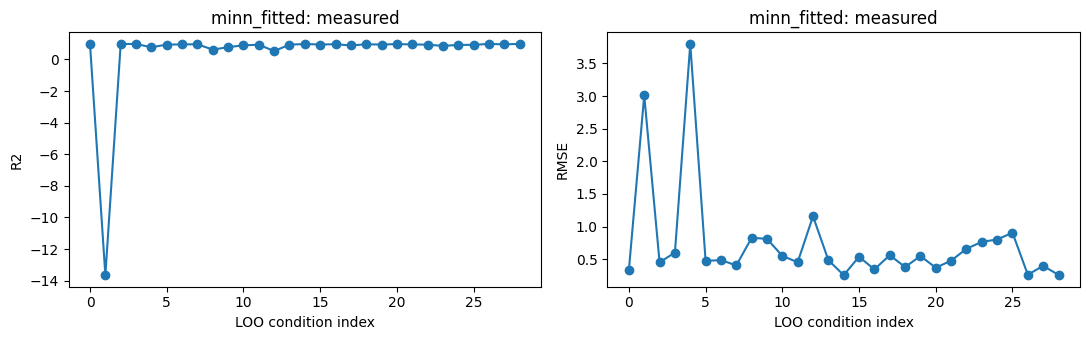

minn_fitted predicted


,R2,Pearson_r2,MAE,RMSE,NE
mean,0.898774,0.937479,0.367336,0.562768,0.231056
<lambda>,0.240365,0.076081,0.369151,0.532145,0.176386


,flux,R2,Pearson_r2,MAE,RMSE,NE
9,PYK_flux,-3.366438,0.359393,1.595147,1.819281,1.001474
3,FBA_flux,0.554653,0.913735,0.796435,1.101733,0.325090
2,PFK_flux,0.679967,0.956106,0.736894,0.933951,0.275583
27,MDH_flux,0.764748,0.880933,0.617638,0.796661,0.216662
23,SUCOAS_flux,0.694013,0.882951,0.610044,1.057693,0.332933
11,G6PDH2r_flux,-0.164382,0.027329,0.590585,1.075674,0.803759
12,PGL_flux,-0.072906,0.122881,0.590373,1.032557,0.771541
10,PDH_flux,-0.352843,0.073840,0.578223,1.346844,0.375787
24,AKGDH_flux,0.503874,0.742839,0.542402,0.721383,0.329420
25,SUCDi_flux,0.767998,0.907948,0.517297,0.859307,0.250686


,source,role,min,max,mean,observed_mean
0,R_EX_glc__D_e_rev,latent prediction,1.878696,11.109390,3.452830,3.880190
1,R_EX_o2_e_rev,latent prediction,1.370240,27.421875,12.039263,9.602583
2,R_EX_co2_e_fwd,latent prediction,1.202857,35.718750,13.382280,7.989683
3,R_EX_etoh_e,latent prediction,0.003817,21.390625,5.634841,0.011659
4,R_EX_ac_e,latent prediction,0.000873,2.124348,0.372834,0.083952


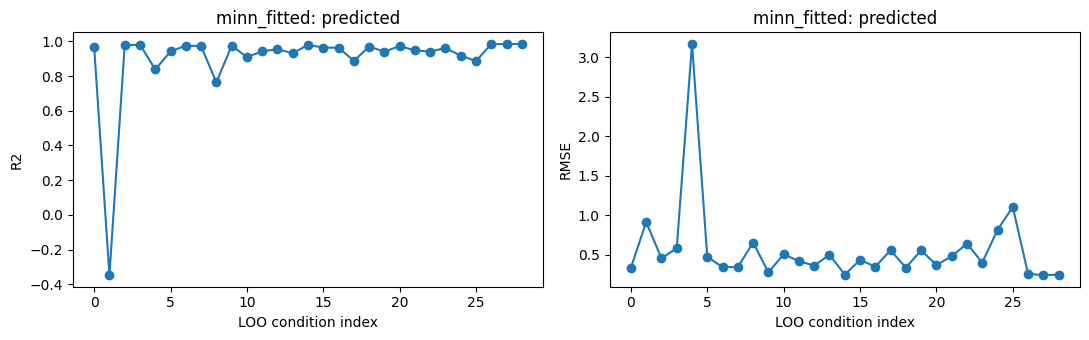

In [19]:
if RUN_MINN:
    direct_summary = pd.DataFrame([{"target_mode": target, "context_mode": mode, **result["pooled"]}
        for (target, mode), result in minn_results.items()])
    display(direct_summary)
    direct_summary.to_csv(run_dir / "minn_direct_summary.csv", index=False)
    for (target, mode), result in minn_results.items():
        print(target, mode)
        display(result["per_sample"].drop(columns="sample").agg(["mean", lambda x: x.std(ddof=0)]))
        display(result["per_flux"].sort_values("MAE", ascending=False).head(10))
        context_rows = []
        for j, source in enumerate(ev.CONTEXT_SOURCES):
            values = result["context"][:, j]
            context_rows.append({"source": source, "role": "copied" if mode == "measured" and j < 2 else "latent prediction",
                "min": values.min(), "max": values.max(), "mean": values.mean(),
                "observed_mean": minn_data[target]["context_truth"][:, j].mean()})
        display(pd.DataFrame(context_rows))
        pd.DataFrame(context_rows).to_csv(run_dir / "minn" / target / mode / "context_diagnostics.csv", index=False)
        fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
        for ax, metric in zip(axes, ["R2", "RMSE"]):
            ax.plot(result["per_sample"][metric].to_numpy(), "o-")
            ax.set(xlabel="LOO condition index", ylabel=metric, title=f"{target}: {mode}")
        fig.tight_layout()
        fig.savefig(pic_dir / f"{model_name}_{target}_{mode}_loo.png", dpi=180)
        plt.show()


## pFBA baseline and both reservoir-to-pFBA variants

All methods preserve the same iML1515 SBML background medium and core objective. Glucose/O2 are observed uptake lower-bound caps, not equality constraints. The reservoir's MINN input vector follows its pretraining base-50 contract; the downstream mechanistic baseline follows the maintained Table 4 SBML medium. The downstream pFBA fraction is 1.0, matching model C. OOF CO2/ethanol/acetate predictions become nonnegative secretion upper caps. Every sample retains a solver status.

In [20]:
if RUN_MINN:
    for target, data in minn_data.items():
        pfba_results[target] = {"baseline": ev.run_pfba(XML_PATH, data, fraction=PFBA_FRACTION)}
        display(pfba_results[target]["baseline"]["status"])


,sample,status,error
0,REF,optimal,
1,WT_0.1h-1,optimal,
2,WT_0.4h-1,optimal,
3,WT_0.5h-1,optimal,
4,WT_0.7h-1,optimal,
5,galM,optimal,
6,glk,optimal,
7,pgm,optimal,
8,pgi,optimal,
9,pfkA,optimal,


In [21]:
if RUN_MINN:
    for target, data in minn_data.items():
        for cap_mode in CAP_MODES:
            pfba_results[target][f"measured_{cap_mode}"] = ev.run_pfba(XML_PATH, data,
                minn_results[(target, "measured")]["context"], cap_mode, PFBA_FRACTION)


In [22]:
if RUN_MINN:
    for target, data in minn_data.items():
        for cap_mode in CAP_MODES:
            pfba_results[target][f"predicted_{cap_mode}"] = ev.run_pfba(XML_PATH, data,
                minn_results[(target, "predicted")]["context"], cap_mode, PFBA_FRACTION)


### Compare methods and diagnose binding caps

Report all successes and an explicitly matched common-success subset. Optional cap-set sensitivities are compared separately so their failures cannot change the primary three-method subset. The full 47-flux and non-context-only metric sets are exported. Negative paired MAE change means improvement over baseline. `binding_low_cap` marks a binding secretion cap below its fitted target.

In [23]:
pfba_tables = {}
if RUN_MINN:
    for target, data in minn_data.items():
        for cap_mode in CAP_MODES:
            selected = {key: pfba_results[target][key] for key in
                ("baseline", f"measured_{cap_mode}", f"predicted_{cap_mode}")}
            table = ev.compare_pfba(selected, data, run_dir / "pfba" / target / cap_mode)
            pfba_tables[(target, cap_mode)] = table
            display(table.query("coverage == 'common_success' and targets == 'all'"))
            for method, result in selected.items():
                failed = result["status"].query("status != 'optimal'")
                if len(failed):
                    print(target, method, "failed solves:")
                    display(failed)
                if not result["caps"].empty:
                    print(target, method, "binding caps:")
                    display(result["caps"].sort_values(["binding_low_cap", "slack"], ascending=[False, True]).head(12))


,method,coverage,targets,successes,total,metric,defined,mean,std
10,baseline,common_success,all,29,29,R2,29,0.658478,1.189478
11,baseline,common_success,all,29,29,Pearson_r2,29,0.892825,0.132254
12,baseline,common_success,all,29,29,MAE,29,0.495038,0.365933
13,baseline,common_success,all,29,29,RMSE,29,0.832498,0.633807
14,baseline,common_success,all,29,29,NE,29,0.309400,0.373326
30,measured_co2_etoh_ac_cap,common_success,all,29,29,R2,29,0.740985,0.821467
31,measured_co2_etoh_ac_cap,common_success,all,29,29,Pearson_r2,29,0.907244,0.113010
32,measured_co2_etoh_ac_cap,common_success,all,29,29,MAE,29,0.463551,0.349798
33,measured_co2_etoh_ac_cap,common_success,all,29,29,RMSE,29,0.779373,0.566459
34,measured_co2_etoh_ac_cap,common_success,all,29,29,NE,29,0.283953,0.308735


minn_fitted measured_co2_etoh_ac_cap binding caps:


,sample,source,cap,flux,target,slack,binding,binding_low_cap
11,WT_0.5h-1,R_EX_ac_e,4.027973e-01,4.027973e-01,0.4896,0.0,True,True
75,tktA,R_EX_co2_e_fwd,1.061721e+01,1.061721e+01,11.4681,0.0,True,True
3,WT_0.1h-1,R_EX_co2_e_fwd,2.265784e+00,2.265784e+00,0.8565,0.0,True,False
5,WT_0.1h-1,R_EX_ac_e,5.443254e-01,5.443254e-01,0.0000,0.0,True,False
8,WT_0.4h-1,R_EX_ac_e,6.608198e-01,6.608198e-01,0.0100,0.0,True,False
12,WT_0.7h-1,R_EX_co2_e_fwd,2.406250e+01,2.406250e+01,19.6169,0.0,True,False
20,glk,R_EX_ac_e,5.896420e-07,5.896420e-07,0.0000,0.0,True,False
23,pgm,R_EX_ac_e,2.263200e-03,2.263200e-03,0.0000,0.0,True,False
38,fbaB,R_EX_ac_e,8.000600e-01,8.000600e-01,0.0000,0.0,True,False
47,gpmB,R_EX_ac_e,2.737591e-04,2.737591e-04,0.0000,0.0,True,False


minn_fitted predicted_co2_etoh_ac_cap binding caps:


,sample,source,cap,flux,target,slack,binding,binding_low_cap
8,WT_0.4h-1,R_EX_ac_e,0.000904,0.000904,0.0100,0.0,True,True
3,WT_0.1h-1,R_EX_co2_e_fwd,1.202857,1.202857,0.8565,0.0,True,False
5,WT_0.1h-1,R_EX_ac_e,0.260537,0.260537,0.0000,0.0,True,False
14,WT_0.7h-1,R_EX_ac_e,1.995698,1.995698,1.9350,0.0,True,False
20,glk,R_EX_ac_e,0.005549,0.005549,0.0000,0.0,True,False
23,pgm,R_EX_ac_e,0.001166,0.001166,0.0000,0.0,True,False
26,pgi,R_EX_ac_e,0.017528,0.017528,0.0000,0.0,True,False
35,fbp,R_EX_ac_e,0.008383,0.008383,0.0000,0.0,True,False
38,fbaB,R_EX_ac_e,0.070732,0.070732,0.0000,0.0,True,False
41,gapC,R_EX_ac_e,0.010025,0.010025,0.0000,0.0,True,False


## Completion and exports

AMN growth, direct MINN flux predictions and pFBA flux predictions are separate outcomes. A smaller direct-flux error need not produce better pFBA caps. Skipped optional sections are recorded separately; failed requested runs qualify completeness; no results are copied from historical checkpoints. Each MLP fit, fold assignment, selected epoch count, context prediction and solver status is stored under this run's directory.

In [24]:
completion = {"amn": False, "minn_both_modes": False, "pfba_all_successful": False,
              "simulated_A_B": simulated_summary is not None}
if amn_result is not None:
    completion["amn"] = len(amn_result["oof"]) == 110 * len(AMN_SETTINGS["split_seeds"])
if RUN_MINN:
    completion["minn_both_modes"] = all((target, mode) in minn_results and
        len(minn_results[(target, mode)]["prediction"]) == 29 for target in TARGET_MODES for mode in ("measured", "predicted"))
    completion["pfba_all_successful"] = all(result["success"].all()
        for methods in pfba_results.values() for result in methods.values())
manifest["completion"] = completion
requested_checks = ([completion["amn"]] if RUN_AMN else [])
requested_checks += [completion["minn_both_modes"], completion["pfba_all_successful"]] if RUN_MINN else []
requested_checks += [completion["simulated_A_B"]] if RUN_SIMULATED else []
manifest["status"] = "complete" if requested_checks and all(requested_checks) else "incomplete_or_qualified"
manifest["skipped"] = [name for name, enabled in [("amn", RUN_AMN), ("minn", RUN_MINN), ("full_simulated_A_B", RUN_SIMULATED)] if not enabled]
manifest["finished_utc"] = datetime.now(timezone.utc).isoformat()
ev.save_json(run_dir / "manifest.json", manifest)
display(pd.DataFrame([completion]))
print("Run status:", manifest["status"])
print("Results:", run_dir)
print("Register actual checkpoint/provenance and matched results in docs/experiment_notes/iML1515_sampling_study_notes.md.")


,amn,minn_both_modes,pfba_all_successful,simulated_A_B
0,True,True,True,False


Run status: complete
Results: c:\Users\truok\projects\metabolic-NN\pics\AB_1M_d256_h8_l4_ff1024\AB_union_evaluation\20260917T150631340189Z
Register actual checkpoint/provenance and matched results in docs/experiment_notes/iML1515_sampling_study_notes.md.


In [25]:
# Refresh an older kernel import without discarding trained results.
if not hasattr(ev, "summarize_amn_oof"):
    from importlib import reload
    ev = reload(ev)

# Final experimental evaluation summary (OOF predictions only).
summary_rows = []
metric_names = ("R2", "MAE", "RMSE")


def experimental_summary_row(dataset, method, truth, prediction, target_names, total):
    truth, prediction = np.asarray(truth), np.asarray(prediction)
    valid = np.isfinite(truth).all(axis=1) & np.isfinite(prediction).all(axis=1)
    row = {"Dataset": dataset, "Method": method, "Samples": f"{int(valid.sum())}/{total}",
           "Pooled targets": len(target_names), "Aggregation": "All available OOF samples"}
    values = {key: np.nan for key in metric_names}
    if valid.any():
        values = ev.metrics(truth[valid], prediction[valid])
    row.update({f"Pooled {key}": values[key] for key in metric_names})
    return row


if amn_result is not None:
    means, amn_scores, amn_spread = ev.summarize_amn_oof(
        amn_result["oof"], len(amn_data["ids"]), AMN_SETTINGS["split_seeds"])
    row = experimental_summary_row("AMN", "Frozen reservoir + AMN MLP",
        means[["truth"]].to_numpy(), means[["prediction"]].to_numpy(),
        amn_data["targets"], len(amn_data["ids"]))
    row["Aggregation"] = "Per-medium mean OOF predictions (model C convention)"
    summary_rows.append(row)

for (target_mode, context_mode), result in minn_results.items():
    data = minn_data[target_mode]
    summary_rows.append(experimental_summary_row(f"MINN ({target_mode})",
        f"Direct reservoir: {context_mode} glucose/O2", data["y"], result["prediction"],
        data["targets"], len(data["ids"])))

for target_mode, methods in pfba_results.items():
    data = minn_data[target_mode]
    for method, result in methods.items():
        summary_rows.append(experimental_summary_row(f"MINN ({target_mode})",
            "pFBA baseline" if method == "baseline" else f"Reservoir to pFBA: {method}",
            result["truth"], result["prediction"],
            result["names"], len(data["ids"])))

experimental_summary = pd.DataFrame(summary_rows)
print("EXPERIMENTAL DATA - pooled flux accuracy")
print("AMN pooling covers its single measured growth target.")
print("MINN direct pooling uses non-context targets; pFBA pooling uses all mapped targets.")
print("R2 is regression R-squared. Pooled scores flatten samples and fluxes; they are not mean per-sample scores.")
print("Failed/nonfinite predictions are excluded explicitly in Samples; compare methods with matching coverage.")
if experimental_summary.empty:
    print("No experimental results available. Run the AMN and/or MINN evaluation cells first.")
else:
    numeric_columns = [f"Pooled {key}" for key in metric_names]
    experimental_summary = experimental_summary[["Dataset", "Method", "Samples", "Pooled targets", "Aggregation"] + numeric_columns]
    display(experimental_summary.style.format({column: "{:.4f}" for column in numeric_columns}, na_rep="undefined").hide(axis="index"))
    experimental_summary.to_csv(run_dir / "experimental_final_summary.csv", index=False)
    if amn_result is None:
        print("AMN evaluation has not been run.")
    for target_mode in TARGET_MODES:
        missing_modes = [mode for mode in ("measured", "predicted") if (target_mode, mode) not in minn_results]
        if missing_modes:
            print(f"MINN {target_mode}: missing context runs: {', '.join(missing_modes)}")

# Original MINN Table 4 summary: per-condition Pearson r squared, then mean/SD.
if RUN_MINN:
    for target_mode, methods in pfba_results.items():
        original_summary = pd.DataFrame({
            method: [f"{row['avg']:.6f} +/- {row['std']:.6f}"
                     for _, row in ev.legacy_pfba_summary(result).iterrows()]
            for method, result in methods.items()
        }, index=["R2", "MAE", "RMSE", "NE"])
        print(f"MINN {target_mode}: original per-condition pFBA comparison")
        print("R2 here is squared Pearson correlation; SD is across successful conditions.")
        display(original_summary)
        original_summary.to_csv(run_dir / f"{target_mode}_original_pfba_summary.csv")


EXPERIMENTAL DATA - pooled flux accuracy
AMN pooling covers its single measured growth target.
MINN direct pooling uses non-context targets; pFBA pooling uses all mapped targets.
R2 is regression R-squared. Pooled scores flatten samples and fluxes; they are not mean per-sample scores.
Failed/nonfinite predictions are excluded explicitly in Samples; compare methods with matching coverage.


Dataset,Method,Samples,Pooled targets,Aggregation,Pooled R2,Pooled MAE,Pooled RMSE
AMN,Frozen reservoir + AMN MLP,110/110,1,Per-medium mean OOF predictions (model C convention),0.8747,0.0235,0.0298
MINN (minn_fitted),Direct reservoir: measured glucose/O2,29/29,42,All available OOF samples,0.8403,0.4694,1.0609
MINN (minn_fitted),Direct reservoir: predicted glucose/O2,29/29,42,All available OOF samples,0.9149,0.3673,0.7745
MINN (minn_fitted),pFBA baseline,29/29,47,All available OOF samples,0.8542,0.4950,1.0463
MINN (minn_fitted),Reservoir to pFBA: measured_co2_etoh_ac_cap,29/29,47,All available OOF samples,0.8764,0.4636,0.9635
MINN (minn_fitted),Reservoir to pFBA: predicted_co2_etoh_ac_cap,29/29,47,All available OOF samples,0.8740,0.4639,0.9724


MINN minn_fitted: original per-condition pFBA comparison
R2 here is squared Pearson correlation; SD is across successful conditions.


,baseline,measured_co2_etoh_ac_cap,predicted_co2_etoh_ac_cap
R2,0.892825 +/- 0.132254,0.907244 +/- 0.113010,0.904870 +/- 0.118670
MAE,0.495038 +/- 0.365933,0.463551 +/- 0.349798,0.463897 +/- 0.328794
RMSE,0.832498 +/- 0.633807,0.779373 +/- 0.566459,0.790386 +/- 0.566523
NE,0.309400 +/- 0.373326,0.283953 +/- 0.308735,0.288780 +/- 0.315251
